# ACCESSAI: First Proto

### Pipeline

## Pipeline

A continuación se describe el pipeline completo seguido para la construcción
del modelo de detección de objetos basado en el dataset ROD, desde los
datasets originales hasta la evaluación final del modelo entrenado.

### Diagrama del pipeline

```
[1] Datasets originales
    ├── ROD-25cls (25 clases, formato detección)
    └── Curbs (formato segmentación)
         │
         ▼
[2] Conversión curbs → detección
    └── curbs_yolo_det (1 clase, bbox)
         │
         ▼
[3] Fusión ROD + curbs → ROD-5cls
    ├── Mapeo 25 → 4
    ├── Fusión con curbs (clase 4)
    └── data.yaml
         │
         ▼
[4] Verificación del dataset fusionado
    ├── 15.172 train / 2.843 valid / 1.327 test
    └── Distribución confirmada
         │
         ▼
[5] Augmentation selectivo
    ├── Leer ROD-5cls
    ├── Aumentar clases minoritarias (×3)
    └── Generar ROD-5cls-augmented
         │
         ▼
[6] Fusión original + augmented
    └── ROD-5cls-final (dataset con clases equilibradas)
         │
         ▼
[7] Reentrenamiento
    └── YOLO26s sobre ROD-5cls-final
         │
         ▼
[8] Evaluación y comparación
```

### Descripción de cada paso

**[1] Datasets originales**

Se parte de dos datasets:
- **ROD-25cls**: 25 clases, formato detección, 24.326 imágenes (19.186 train / 3.511 valid / 1.629 test).
- **Curbs**: dataset externo de bordillos, formato segmentación, 1.432 imágenes.

**[2] Conversión curbs → detección**

Los polígonos de segmentación de curbs se convierten a bounding boxes
para homogeneizar el formato con ROD-25cls.

**[3] Fusión ROD + curbs → ROD-5cls**

Se aplica un mapeo de las 25 clases originales de ROD a 4 clases funcionales
orientadas a accesibilidad urbana:

| Clase nueva | Clases originales |
|-------------|-------------------|
| Obstaculo_Dinamico | Bike, Car, Person, Motorcycle, Truck, Bus |
| Obstaculo_Fijo | Traffic sign, Electrical Pole, Dustbin, Manhole, Tree, Guard rail, Bench, Fire hydrant, Plant Pot, Electrical Box, Chair, Bicycle Rack |
| Barrera_Arquitectonica | Stairs |
| Elemento_Peatonal | Pedestrian crosswalk |

Clases eliminadas: Building, Road, Dog, Traffic Cone, Traffic Barrel.

Se añade la clase `Bordillo` (índice 4) proveniente del dataset de curbs.

**[4] Verificación**

Comprobación de estructura y distribución:
- 15.172 train / 2.843 valid / 1.327 test.
- Ratio de desbalanceo: **14:1**.

**[5] Augmentation selectivo**

Se generan versiones aumentadas de las imágenes que contienen clases
minoritarias (Barrera_Arquitectonica, Bordillo, Elemento_Peatonal) con
transformaciones moderadas:
- Rotación (±10°).
- Cambio de brillo/contraste.
- Espejo horizontal.
- Ruido gaussiano suave.

Factor de aumento: ×3.

**[6] Fusión original + augmented**

Se combinan el dataset original y el augmentado:
- Train: 24.136 imágenes (15.172 + 8.964 aumentadas).
- Valid y test: sin cambios.
- Ratio de desbalanceo: **3,4:1**.

**[7] Reentrenamiento**

Entrenamiento del modelo YOLO26s sobre el dataset aumentado.

**[8] Evaluación y comparación**

Evaluación sobre el conjunto de test y comparación con los modelos previos
(ROD-25cls, ROD-8cls, ROD-5cls).

In [2]:
from ultralytics import YOLO

import torch
import os
import yaml
import requests
import random
import shutil
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
import albumentations as A

from pathlib import Path
from collections import Counter

/home/JNB/anaconda3/envs/yoloEnv/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [3]:
print(f"¿GPU disponible? {torch.cuda.is_available()}")
print(f"Dispositivo: {torch.cuda.get_device_name(0)}")
print(f"Versión HIP: {torch.version.hip}")

¿GPU disponible? True
Dispositivo: AMD Radeon RX 9060 XT
Versión HIP: 7.13.99004


## ROD Dataset + Curbs Dataset: detección de objetos

In [3]:
ROD_PATH = "datasets/rod_25cls/" 
CURBS_PATH = "datasets/curbs/"

### Comprobar estructura de los datasets

In [4]:
def show_dataset(dataset_path, name):

    print(f"ESTRUCTURA DEL DATASET: {name}")

    dataset = Path(dataset_path)

    if not dataset.exists():
        print(f"ERROR: la ruta no existe")
        return

    for split in ["train", "valid", "test"]:
        split_dir = dataset / split

        if not split_dir.exists():
            print(f"  {split:5s}: NO EXISTE")
            continue

        img_dir = split_dir / "images"
        lbl_dir = split_dir / "labels"

        n_imgs = len(list(img_dir.glob("*"))) if img_dir.exists() else 0
        n_lbls = len(list(lbl_dir.glob("*.txt"))) if lbl_dir.exists() else 0

        print(f"  {split:5s}: {n_imgs:>6d} imágenes, {n_lbls:>6d} labels")

In [5]:
show_dataset(ROD_PATH, "ROD")

ESTRUCTURA DEL DATASET: ROD
  train:  19186 imágenes,  19186 labels
  valid:   3511 imágenes,   3511 labels
  test :   1629 imágenes,   1629 labels


In [6]:
show_dataset(CURBS_PATH, "Curbs")

ESTRUCTURA DEL DATASET: Curbs
  train:    955 imágenes,    955 labels
  valid:    270 imágenes,    270 labels
  test :    207 imágenes,    207 labels


### Distribución de instancias por clase

In [7]:
def show_class_distribution(dataset_path, name):
    # Distribución de clases en el split de train
    print(f"DISTRIBUCIÓN DE CLASES — {name} (train)")

    # Leer el data.yaml para obtener los nombres de clase
    yaml_path = os.path.join(dataset_path, "data.yaml")
    
    with open(yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)
    names = data_config.get('names', [])

    # Contar instancias en train
    train_lbl_dir = os.path.join(dataset_path, "train", "labels")
    if not os.path.exists(train_lbl_dir):
        print(f"  No existe el directorio: {train_lbl_dir}")
        return

    contador = Counter()
    for lbl_file in os.listdir(train_lbl_dir):
        with open(os.path.join(train_lbl_dir, lbl_file)) as f:
            for line in f:
                if line.strip():
                    contador[int(line.split()[0])] += 1

    total = sum(contador.values())

    # Imprimir tabla ordenada por número de instancias (descendente)
    print(f"{'#':>3s}  {'Clase':25s} {'Instancias':>10s} {'%':>7s}")
    print("-" * 50)
    
    for i, count in sorted(contador.items(), key=lambda x: -x[1]):
        nombre = names[i] if i < len(names) else f"Clase {i}"
        pct = count / total * 100 if total > 0 else 0
        print(f"{i:>3d}  {nombre:25s} {count:>10d} {pct:>6.2f}%")
        
    print("-" * 50)
    print(f"{'':>3s}  {'TOTAL':25s} {total:>10d}")


In [8]:
show_class_distribution(ROD_PATH, "ROD-25cls")
show_class_distribution(CURBS_PATH, "Curbs")


DISTRIBUCIÓN DE CLASES — ROD-25cls (train)
  #  Clase                     Instancias       %
--------------------------------------------------
  3  Person                          7609  23.59%
  2  Car                             4328  13.42%
 14  Pedestrian crosswalk            1875   5.81%
 11  Manhole                         1779   5.52%
 23  Chair                           1757   5.45%
 12  Tree                            1632   5.06%
 13  Guard rail                      1385   4.29%
  9  Dustbin                         1351   4.19%
  4  Stairs                          1125   3.49%
 16  Bus                             1009   3.13%
  8  Motorcycle                       888   2.75%
  1  Building                         886   2.75%
 17  Bench                            706   2.19%
  5  Traffic sign                     689   2.14%
 18  Traffic Cone                     678   2.10%
 10  Dog                              633   1.96%
 15  Truck                            621   1.93%
  7  

#### Ratio original ROD-DATASET con 25 clases - 44:1

### Conversión de Curbs: de segmentación a detección con bbs

In [9]:

INPUT = Path("datasets/curbs")
OUTPUT = Path("datasets/curbs_yolo_det")


CLASE_PROVISIONAL = 0

def poligono_a_bbox(coords):
    xs = coords[0::2]  # coordenadas x
    ys = coords[1::2]  # coordenadas y

    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)

    cx = (x_min + x_max) / 2
    cy = (y_min + y_max) / 2
    w = x_max - x_min
    h = y_max - y_min

    return cx, cy, w, h


def procesar_split(split_name):
    src_img = INPUT / split_name / "images"
    src_lbl = INPUT / split_name / "labels"
    dst_img = OUTPUT / split_name / "images"
    dst_lbl = OUTPUT / split_name / "labels"

    dst_img.mkdir(parents=True, exist_ok=True)
    dst_lbl.mkdir(parents=True, exist_ok=True)

    n_imgs = 0
    n_labels_converted = 0
    n_instancias_validas = 0
    n_instancias_invalidas = 0

    for lbl_path in src_lbl.glob("*.txt"):
        nuevas_lineas = []

        with open(lbl_path) as f:
            for line in f:
                partes = line.strip().split()
                if len(partes) < 5:
                    continue  # línea vacía o mal formada

                # Detectar tipo: 5 valores = detección, ≥7 = segmentación
                n_valores = len(partes)

                if n_valores == 5:
                    # Ya es bbox, solo renombrar clase
                    nuevas_lineas.append(
                        f"{CLASE_PROVISIONAL} {' '.join(partes[1:])}"
                    )
                    n_instancias_validas += 1
                elif n_valores >= 7 and n_valores % 2 == 1:
                    # Es polígono (1 + 2*N valores)
                    coords = [float(x) for x in partes[1:]]
                    cx, cy, w, h = poligono_a_bbox(coords)
                    nuevas_lineas.append(
                        f"{CLASE_PROVISIONAL} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}"
                    )
                    n_instancias_validas += 1
                else:
                    n_instancias_invalidas += 1

        if not nuevas_lineas:
            continue  # no escribir label vacío

        # Copiar imagen
        for ext in [".jpg", ".jpeg", ".png"]:
            img_path = src_img / (lbl_path.stem + ext)
            if img_path.exists():
                shutil.copy2(img_path, dst_img / img_path.name)
                break

        # Escribir label convertido
        with open(dst_lbl / lbl_path.name, "w") as f:
            f.write("\n".join(nuevas_lineas))

        n_imgs += 1
        n_labels_converted += 1

    print(f"{split_name:6s} → {n_imgs} imgs procesadas, "
          f"{n_labels_converted} labels escritos, "
          f"{n_instancias_validas} instancias válidas, "
          f"{n_instancias_invalidas} inválidas")


print("Conversión curbs (segmentación) → curbs_yolo_det (detección) \n")

for split in ["train", "valid", "test"]:
    procesar_split(split)

print(f"\n✓ Dataset convertido en: {OUTPUT}/")

Conversión curbs (segmentación) → curbs_yolo_det (detección) 

train  → 955 imgs procesadas, 955 labels escritos, 1113 instancias válidas, 0 inválidas
valid  → 270 imgs procesadas, 270 labels escritos, 316 instancias válidas, 0 inválidas
test   → 207 imgs procesadas, 207 labels escritos, 237 instancias válidas, 0 inválidas

✓ Dataset convertido en: datasets/curbs_yolo_det/


### Mapero de ROD: 4 superclases

In [22]:
ROD_PATH = Path("datasets/rod_25cls")
CURBS_PATH = Path("datasets/curbs_yolo_det")  # Curbs convertido a detección estándar con bbs
OUTPUT = Path("datasets/rod_5cls")

MAPEO_ROD = {
    0: 0,    # Bike → Obstaculo_Dinamico
    1: -1,   # Building → ELIMINAR
    2: 0,    # Car → Obstaculo_Dinamico
    3: 0,    # Person → Obstaculo_Dinamico
    4: 2,    # Stairs → Barrera_Arquitectonica
    5: 1,    # Traffic sign → Obstaculo_Fijo
    6: 1,    # Electrical Pole → Obstaculo_Fijo
    7: -1,   # Road → ELIMINAR
    8: 0,    # Motorcycle → Obstaculo_Dinamico
    9: 1,    # Dustbin → Obstaculo_Fijo
    10: -1,  # Dog → ELIMINAR
    11: 1,   # Manhole → Obstaculo_Fijo
    12: 1,   # Tree → Obstaculo_Fijo
    13: 1,   # Guard rail → Obstaculo_Fijo
    14: 4,   # Pedestrian crosswalk → Elemento_Peatonal
    15: 0,   # Truck → Obstaculo_Dinamico
    16: 0,   # Bus → Obstaculo_Dinamico
    17: 1,   # Bench → Obstaculo_Fijo
    18: -1,  # Traffic Cone → ELIMINAR
    19: 1,   # Fire hydrant → Obstaculo_Fijo
    20: -1,  # Traffic Barrel → ELIMINAR
    21: 1,   # Plant Pot → Obstaculo_Fijo
    22: 1,   # Electrical Box → Obstaculo_Fijo
    23: 1,   # Chair → Obstaculo_Fijo
    24: 1,   # Bicycle Rack → Obstaculo_Fijo
}

CLASE_CURB = 3

In [23]:
def aplicar_mapeo_rod(src_root, dst_root):
    # Aplica el mapeo 25 → 4 a ROD-25cls
    
    for split in ["train", "valid", "test"]:
        src_img = src_root / split / "images"
        src_lbl = src_root / split / "labels"
        dst_img = dst_root / split / "images"
        dst_lbl = dst_root / split / "labels"

        dst_img.mkdir(parents=True, exist_ok=True)
        dst_lbl.mkdir(parents=True, exist_ok=True)

        n_imgs = 0
        n_inst_validas = 0
        n_inst_eliminadas = 0

        for lbl_path in src_lbl.glob("*.txt"):
            nuevas_lineas = []

            with open(lbl_path) as f:
                for line in f:
                    partes = line.strip().split()
                    if len(partes) != 5:
                        continue  # solo detección (5 valores)

                    clase_orig = int(partes[0])
                    nueva = MAPEO_ROD.get(clase_orig, -1)

                    if nueva == -1:
                        n_inst_eliminadas += 1
                        continue

                    nuevas_lineas.append(f"{nueva} {' '.join(partes[1:])}")
                    n_inst_validas += 1

            if not nuevas_lineas:
                continue  # no copiar imágenes sin etiquetas útiles

            # Copiar imagen
            for ext in [".jpg", ".jpeg", ".png"]:
                img = src_img / (lbl_path.stem + ext)
                if img.exists():
                    shutil.copy2(img, dst_img / img.name)
                    break

            # Escribir label convertido
            with open(dst_lbl / lbl_path.name, "w") as f:
                f.write("\n".join(nuevas_lineas))

            n_imgs += 1

        print(f"  {split:6s} → {n_imgs} imgs, {n_inst_validas} inst. válidas, {n_inst_eliminadas} eliminadas")


In [24]:
def fusionar_curbs(curbs_root, dst_root):
    # Añade las imágenes de curbs al dataset base, con la clase CLASE_CURB
    
    for split in ["train", "valid", "test"]:
        src_img = curbs_root / split / "images"
        src_lbl = curbs_root / split / "labels"
        dst_img = dst_root / split / "images"
        dst_lbl = dst_root / split / "labels"

        n_imgs = 0
        n_inst = 0

        for lbl_path in src_lbl.glob("*.txt"):
            nuevas_lineas = []

            with open(lbl_path) as f:
                for line in f:
                    partes = line.strip().split()
                    if len(partes) != 5:
                        continue
                    nuevas_lineas.append(f"{CLASE_CURB} {' '.join(partes[1:])}")
                    n_inst += 1

            if not nuevas_lineas:
                continue

            # Copiar imagen con prefijo para evitar colisiones de nombre
            for ext in [".jpg", ".jpeg", ".png"]:
                img = src_img / (lbl_path.stem + ext)
                if img.exists():
                    nuevo_nombre = f"curb_{img.name}"
                    shutil.copy2(img, dst_img / nuevo_nombre)
                    break

            # Escribir label con el mismo prefijo
            with open(dst_lbl / f"curb_{lbl_path.name}", "w") as f:
                f.write("\n".join(nuevas_lineas))

            n_imgs += 1

        print(f"  {split:6s} → {n_imgs} imgs, {n_inst} instancias de Curb")

In [25]:
def crear_data_yaml(output_root):
    yaml_content = """train: ../train/images
val: ../valid/images
test: ../test/images

nc: 5
names: ['Obstaculo_Dinamico', 'Obstaculo_Fijo', 'Barrera_Arquitectonica', 'Bordillo', 'Elemento_Peatonal']
"""
    with open(output_root / "data.yaml", "w") as f:
        f.write(yaml_content)
        
    print(f"\n  data.yaml creado en: {output_root / 'data.yaml'}")

In [26]:
def verificar_dataset_final(root):
    # Verifica el dataset final
    
    print(f"\n{'='*60}")
    print("VERIFICACIÓN DEL DATASET FINAL")
    print(f"{'='*60}")

    for split in ["train", "valid", "test"]:
        imgs = list((root / split / "images").glob("*"))
        lbls = list((root / split / "labels").glob("*.txt"))
        print(f"  {split:6s}: {len(imgs):>6d} imágenes, {len(lbls):>6d} labels")

    print(f"\nDistribución de clases (train):")
    contador = Counter()
    for lbl in (root / "train" / "labels").glob("*.txt"):
        with open(lbl) as f:
            for line in f:
                if line.strip():
                    contador[int(line.split()[0])] += 1

    
    names = ['Obstaculo_Dinamico', 'Obstaculo_Fijo', 'Barrera_Arquitectonica', 'Bordillo', 'Elemento_Peatonal']
    total = sum(contador.values())
    for i, nombre in enumerate(names):
        c = contador.get(i, 0)
        print(f"  [{i}] {nombre:25s} {c:>7d}  ({c/total*100:5.2f}%)")
        
    print(f"  {'':29s} {'TOTAL':>7s}: {total}")

In [27]:
aplicar_mapeo_rod(ROD_PATH, OUTPUT)  # Mapeo 25-4 a ROD-25cls
fusionar_curbs(CURBS_PATH, OUTPUT) # Fusión con Curbs
crear_data_yaml(OUTPUT)  # Creación de data.yaml de dataset definitivo
verificar_dataset_final(OUTPUT)

  train  → 14217 imgs, 25718 inst. válidas, 2618 eliminadas
  valid  → 2573 imgs, 4442 inst. válidas, 322 eliminadas
  test   → 1120 imgs, 1785 inst. válidas, 172 eliminadas
  train  → 955 imgs, 1113 instancias de Curb
  valid  → 270 imgs, 316 instancias de Curb
  test   → 207 imgs, 237 instancias de Curb

  data.yaml creado en: datasets/rod_5cls/data.yaml

VERIFICACIÓN DEL DATASET FINAL
  train :  15172 imágenes,  15172 labels
  valid :   2843 imágenes,   2843 labels
  test  :   1327 imágenes,   1327 labels

Distribución de clases (train):
  [0] Obstaculo_Dinamico          14697  (54.78%)
  [1] Obstaculo_Fijo               8182  (30.49%)
  [2] Barrera_Arquitectonica       1070  ( 3.99%)
  [3] Bordillo                     1113  ( 4.15%)
  [4] Elemento_Peatonal            1769  ( 6.59%)
                                  TOTAL: 26831


#### -21% de las imágenes por las clases eliminadas, retención del 83% de las instancias relevantes para accesibilidad
#### Hemos perdido algunas instancias de Barrera Arquitectónica (Stairs) y Elemento peatonal (Pedestrian crosswalk) puede deberse a duplicados o al filtrado de imágenes
#### RATIO RESULTANTE - 13.7:1

### Augmentation selectivo a clases minoritarias en ROD-Dataset 5cls

In [14]:
DATASET_SRC = Path("datasets/rod_5cls")
DATASET_DST = Path("datasets/rod_5cls_augmented")

# [2] Barrera_Arquitectonica, [3] Bordillo, [4] Elemento_Peatonal
CLASES_MINORITARIAS = [2, 3, 4]
FACTOR_AUMENTO = 3 # Versiones extra por imagen original

random.seed(42)

# Transformaciones de augmentation
TRANSFORM = A.Compose([
    A.HorizontalFlip(p=0.5), # Flip hortizontal
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.4), # Brillo y contraste
    A.Rotate(limit=5, p=0.3, border_mode=cv2.BORDER_REFLECT_101),  # Rotación
], bbox_params=A.BboxParams(
    format='yolo',
    label_fields=['class_labels'],
    min_visibility=0.3,
))

In [15]:
def leer_label(lbl_path):
    # Lee un archivo .txt y devuelve listas de clases y bboxes
    
    clases = []
    bboxes = []
    
    with open(lbl_path) as f:
        for line in f:
            partes = line.strip().split()
            if len(partes) != 5:
                continue
            clases.append(int(partes[0]))
            bboxes.append([float(x) for x in partes[1:]])
            
    return clases, bboxes

In [16]:
def escribir_label(lbl_path, clases, bboxes):
    # Escribe un archivo .txt con clases y bboxes
    
    with open(lbl_path, "w") as f:
        for c, b in zip(clases, bboxes):
            f.write(f"{int(c)} {b[0]:.6f} {b[1]:.6f} {b[2]:.6f} {b[3]:.6f}\n")

In [18]:
def copiar_split(split_name):
    # Copia un split completo (train/valid/test) al dataset destino
    
    src_img = DATASET_SRC / split_name / "images"
    src_lbl = DATASET_SRC / split_name / "labels"
    dst_img = DATASET_DST / split_name / "images"
    dst_lbl = DATASET_DST / split_name / "labels"

    dst_img.mkdir(parents=True, exist_ok=True)
    dst_lbl.mkdir(parents=True, exist_ok=True)

    n_copiadas = 0
    for lbl_path in src_lbl.glob("*.txt"):
        # Buscar la imagen asociada
        img_found = None
        for ext in [".jpg", ".jpeg", ".png"]:
            img_path = src_img / (lbl_path.stem + ext)
            if img_path.exists():
                img_found = img_path
                break
        if img_found is None:
            continue

        shutil.copy2(img_found, dst_img / img_found.name)
        shutil.copy2(lbl_path, dst_lbl / lbl_path.name)
        n_copiadas += 1

    print(f"  {split_name:6s}: {n_copiadas} imágenes copiadas")
    
    return n_copiadas

In [19]:
def aumentar_train():
    # Genera imágenes aumentadas de las clases minoritarias en train
    
    src_img = DATASET_SRC / "train" / "images"
    src_lbl = DATASET_SRC / "train" / "labels"
    dst_img = DATASET_DST / "train" / "images"
    dst_lbl = DATASET_DST / "train" / "labels"

    n_originales_con_min = 0
    n_aug_generadas = 0
    n_fallidas = 0

    for lbl_path in src_lbl.glob("*.txt"):
        clases, bboxes = leer_label(lbl_path)

        # ¿Contiene alguna clase minoritaria?
        if not any(c in CLASES_MINORITARIAS for c in clases):
            continue

        n_originales_con_min += 1

        # Buscar imagen
        img_path = None
        for ext in [".jpg", ".jpeg", ".png"]:
            candidate = src_img / (lbl_path.stem + ext)
            if candidate.exists():
                img_path = candidate
                break
        if img_path is None:
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            continue

        # Generar N versiones aumentadas
        for i in range(FACTOR_AUMENTO):
            try:
                transformed = TRANSFORM(image=img, bboxes=bboxes, class_labels=clases)
            except Exception as e:
                n_fallidas += 1
                continue

            aug_img = transformed["image"]
            aug_bboxes = transformed["bboxes"]
            aug_clases = transformed["class_labels"]

            if not aug_bboxes:
                n_fallidas += 1
                continue

            out_name = f"{lbl_path.stem}_aug{i}"
            cv2.imwrite(str(dst_img / f"{out_name}.jpg"), aug_img)
            escribir_label(dst_lbl / f"{out_name}.txt", aug_clases, aug_bboxes)
            n_aug_generadas += 1

    print(f"  Imágenes con clase minoritaria: {n_originales_con_min}")
    print(f"  Versiones aumentadas generadas: {n_aug_generadas}")
    print(f"  Fallidas (artefactos): {n_fallidas}")

In [20]:
def crear_data_yaml():
    # Crea el data.yaml del dataset aumentado
    
    yaml_content = """train: ../train/images
val: ../valid/images
test: ../test/images

nc: 5
names: ['Obstaculo_Dinamico', 'Obstaculo_Fijo', 'Barrera_Arquitectonica', 'Bordillo', 'Elemento_Peatonal']
"""
    
    with open(DATASET_DST / "data.yaml", "w") as f:
        f.write(yaml_content)
        
    print(f"  data.yaml creado en: {DATASET_DST / 'data.yaml'}")

In [21]:
print("AUGMENTATION SELECTIVO + FUSIÓN")

# Limpiar el dataset destino si existe
if DATASET_DST.exists():
    print(f"\n El dataset destino ya existe. Eliminando...")
    shutil.rmtree(DATASET_DST)
    print(f"  Eliminado: {DATASET_DST}")

print(f"\n1. Copiando dataset original a {DATASET_DST}...")
for split in ["train", "valid", "test"]:
    copiar_split(split)

print(f"\n2. Generando imágenes aumentadas de clases minoritarias...")
aumentar_train()

print(f"\n3. Creando data.yaml...")
crear_data_yaml()

print("✓ Augmentation completado")

AUGMENTATION SELECTIVO + FUSIÓN

1. Copiando dataset original a datasets/rod_5cls_augmented...
  train : 15172 imágenes copiadas
  valid : 2843 imágenes copiadas
  test  : 1327 imágenes copiadas

2. Generando imágenes aumentadas de clases minoritarias...
  Imágenes con clase minoritaria: 3040
  Versiones aumentadas generadas: 8964
  Fallidas (artefactos): 156

3. Creando data.yaml...
  data.yaml creado en: datasets/rod_5cls_augmented/data.yaml
✓ Augmentation completado


In [22]:
# Mostramos aleatoriamente algunos labels para comprobar que se han formado correctamente

lbl_dir = Path("datasets/rod_5cls_augmented/train/labels")
aug_labels = list(lbl_dir.glob("*_aug*.txt"))

if aug_labels:
    sample = aug_labels[0]
    
    print(f"Muestra: {sample.name}")
    with open(sample) as f:
        print(f.read())
else:
    print("No se encontraron labels aumentados")

Muestra: IMG_00485_aug0.txt
2 0.489844 0.503906 0.914844 0.920313



In [24]:
# Verificación del ROD-Dataset de 5 clases aumentado

DATASET = Path("datasets/rod_5cls_augmented")

print("Estructura:")
for split in ["train", "valid", "test"]:
    imgs = list((DATASET / split / "images").glob("*"))
    lbls = list((DATASET / split / "labels").glob("*.txt"))
    print(f"  {split:6s}: {len(imgs):>6d} imgs, {len(lbls):>6d} labels")

print("\nDistribución de clases (train):")
contador = Counter()
for lbl in (DATASET / "train" / "labels").glob("*.txt"):
    with open(lbl) as f:
        for line in f:
            if line.strip():
                contador[int(line.split()[0])] += 1

names = ['Obstaculo_Dinamico', 'Obstaculo_Fijo', 'Barrera_Arquitectonica', 'Bordillo', 'Elemento_Peatonal']
total = sum(contador.values())
for i, nombre in enumerate(names):
    c = contador.get(i, 0)
    print(f"  [{i}] {nombre:25s} {c:>7d}  ({c/total*100:5.2f}%)")
print(f"  {'':29s} {'TOTAL':>7s}: {total}")


mayor = max(contador.values())
menor = min(contador.values())
print(f"\nRatio mayor/menor: {mayor/menor:.1f}:1")

Estructura:
  train :  24136 imgs,  24136 labels
  valid :   2843 imgs,   2843 labels
  test  :   1327 imgs,   1327 labels

Distribución de clases (train):
  [0] Obstaculo_Dinamico          14805  (38.33%)
  [1] Obstaculo_Fijo               8188  (21.20%)
  [2] Barrera_Arquitectonica       4283  (11.09%)
  [3] Bordillo                     4273  (11.06%)
  [4] Elemento_Peatonal            7077  (18.32%)
                                  TOTAL: 38626

Ratio mayor/menor: 3.5:1


### Entrenamiento

In [85]:
!rocm-smi  # Para GPU AMD



============================================= ROCm System Management Interface =============================================
======================================================= Concise Info =======================================================
Device  Node  IDs              Temp    Power    Partitions          SCLK     MCLK     Fan     Perf    PwrCap  VRAM%  GPU%  
              (DID,     GUID)  (Edge)  (Avg)    (Mem, Compute, ID)                                                         
0       1     0x7590,   56445  40.0°C  29.0W    N/A, N/A, 0         1613Mhz  1258Mhz  15.69%  manual  200.0W  26%    7%    
1       2     0x164e,   24725  49.0°C  37.233W  N/A, N/A, 0         N/A      3000Mhz  0%      auto    N/A     46%    0%    
=================================================== End of ROCm SMI Log ====================================================


In [ ]:
# Descarga del modelo preentrenado y validación inicial con el dataset
# !yolo val model=yolo26n.pt data=dataset/data.yaml name=val_inicial

In [28]:
model = YOLO("yolo26s.pt")

In [29]:
results = model.train(
    data="datasets/rod_5cls_augmented/data.yaml",
    epochs=40,          
    imgsz=640,          
    batch=16,  # Error con batch 32 para el dataset rod_5cls aumentado
    patience=10,
    close_mosaic=3,
    optimizer="AdamW", # Optimizador explícito
    lr0=0.001, # Learning rate recomendado para AdamW
    # cls_pw=0.5, # Dar más peso a las clases minoritarias
    device=0,    # Activa la GPU
    name="rod_5cls_augmented_yolo26s"
)

New https://pypi.org/project/ultralytics/8.4.164 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.157 🚀 Python-3.11.16 torch-2.11.0+rocm7.13.0 CUDA:0 (AMD Radeon RX 9060 XT, 16304MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=3, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/rod_5cls_augmented/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0

### Métricas del entrenamiento

Durante el entrenamiento, Ultralytics muestra una serie de métricas que reflejan el rendimiento del modelo. Estas son las más importantes:

#### Pérdidas (Losses)

| Métrica | ¿Qué mide? | ¿Qué esperar? |
| :--- | :--- | :--- |
| **box_loss** | Error en la localización de las bounding boxes (coordenadas). | Debe bajar con las épocas. |
| **cls_loss** | Error en la clasificación de cada objeto (¿es un coche? ¿una persona?). | Debe bajar con las épocas. |
| **l1_loss** | Pérdida auxiliar de regresión que ayuda a estabilizar el entrenamiento. | Debe bajar con las épocas. |

#### Métricas de evaluación (Box)

| Métrica | ¿Qué mide? | ¿Qué esperar? |
| :--- | :--- | :--- |
| **Precision (P)** | De todos los objetos que el modelo detecta, ¿cuántos son correctos? | Cuanto más alto, mejor. Cercano a 1.0 es ideal. |
| **Recall (R)** | De todos los objetos reales, ¿cuántos detecta el modelo? | Cuanto más alto, mejor. Cercano a 1.0 es ideal. |
| **mAP50** | Precisión media con un umbral de solapamiento (IoU) del 50%. | Cuanto más alto, mejor. >0.90 es excelente. |
| **mAP50-95** | Precisión media promediada sobre umbrales de IoU de 50% a 95%. | Cuanto más alto, mejor. >0.70 es muy bueno. |

#### Otras métricas

| Métrica | ¿Qué mide? |
| :--- | :--- |
| **Instances** | Número de objetos anotados en el batch actual. |
| **GPU_mem** | Memoria de la GPU utilizada durante el entrenamiento. |
| **Size** | Tamaño de las imágenes de entrada (ej. 640x640). |

#### ¿Qué es el IoU?

El **IoU** (Intersection over Union) mide el solapamiento entre la bounding box predicha y la real. Va de 0 (sin solapamiento) a 1 (solapamiento perfecto). Un IoU de 0.5 significa que la predicción cubre al menos el 50% del objeto real.

#### ¿Qué es el mAP?

El **mAP** (mean Average Precision) es la métrica estándar para evaluar modelos de detección de objetos. Combina Precision y Recall en un solo número. Un mAP alto significa que el modelo detecta los objetos correctamente y con buena localización.

Si el mAP es bueno (>0.90) → Documentar y pasar a la demo.

Si el mAP es bajo (<0.80) → Analizar qué clases fallan y considerar:

    Más épocas.

    Data augmentation específico.

    Ajuste de hiperparámetros con model.tune().

Si la demo falla mucho → Documentar la limitación de dominio y proponer fine-tuning con imágenes locales como trabajo futuro.

In [30]:
model = YOLO("runs/detect/rod_5cls_augmented_yolo26s/weights/best.pt")  # Cargamos el mejor modelo

In [31]:
metrics = model.val(data="datasets/rod_5cls_augmented/data.yaml", split="test", name="val_rod_5cls_augmented")  # Test

Ultralytics 8.4.157 🚀 Python-3.11.16 torch-2.11.0+rocm7.13.0 CUDA:0 (AMD Radeon RX 9060 XT, 16304MiB)
YOLO26s summary (fused): 120 layers, 9,467,115 parameters, 0 gradients, 20.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 222.1±99.7 MB/s, size: 78.5 KB)
val: Scanning /home/JNB/Sync/PythonAI&ML/ProyectoAI/datasets/rod_5cls_augmented/test/labels... 1327 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1327/1327 5.2Kit/s 0.3s0.1s
val: New cache created: /home/JNB/Sync/PythonAI&ML/ProyectoAI/datasets/rod_5cls_augmented/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 83/83 8.5it/s 9.8s0.1s
                   all       1327       2022      0.875      0.814      0.863      0.675
    Obstaculo_Dinamico        347        738      0.929       0.83      0.917      0.674
        Obstaculo_Fijo        505        658      0.917      0.878      0.924      0.755
Barrera_Arquitectonica        144        214  

In [32]:
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

mAP50: 0.8631
mAP50-95: 0.6752
Precision: 0.8745
Recall: 0.8137


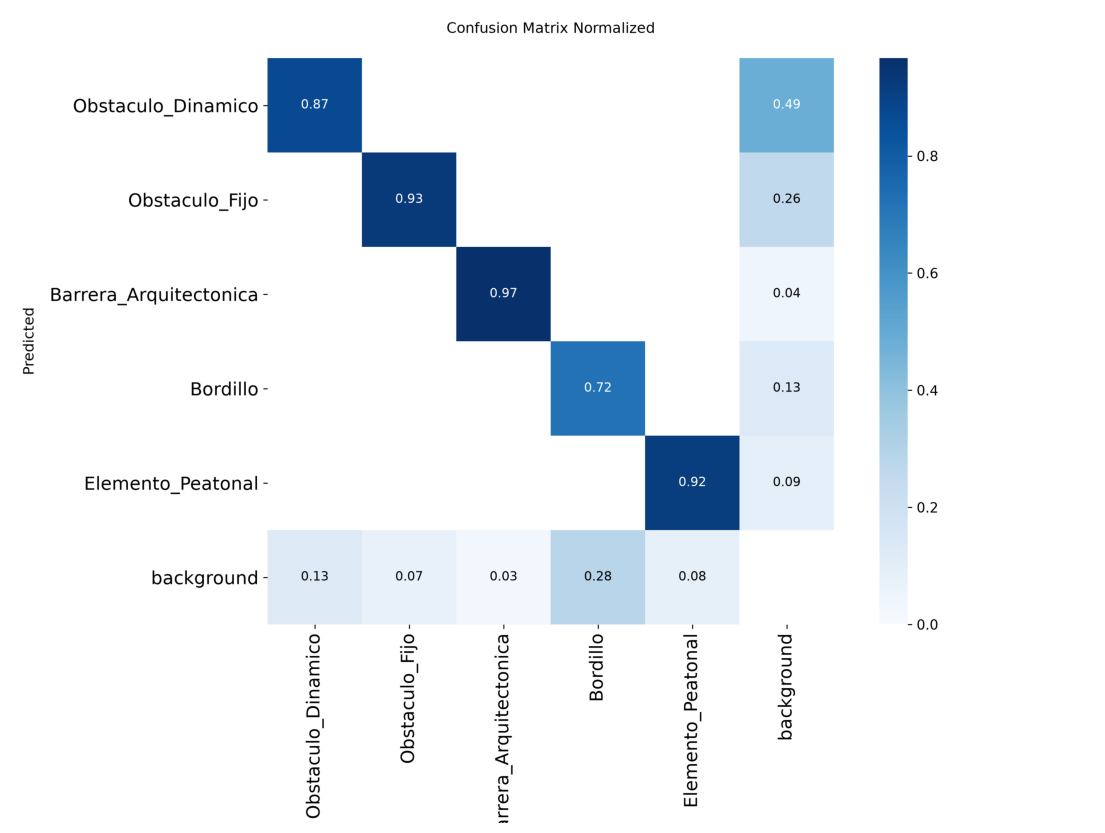

In [33]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("runs/detect/rod_5cls_augmented_yolo26s/confusion_matrix_normalized.png")  # Matriz de confusión normalizada
plt.figure(figsize=(14, 12))
plt.imshow(img)
plt.axis('off')
plt.show()

### Predicción con imágenes propias

In [118]:
model = YOLO("runs/detect/rod_5cls_augmented_yolo26s/weights/best.pt")

for idx, name in model.names.items():
    print(f"  {idx}: {name}")
    
print(f"\nClases: {len(model.names)}")

  0: Obstaculo_Dinamico
  1: Obstaculo_Fijo
  2: Barrera_Arquitectonica
  3: Bordillo
  4: Elemento_Peatonal

Clases: 5


In [120]:
imgs_dir = Path("predicts/imgs/")
output_dir = Path("predicts/5cls-aug/")
output_dir.mkdir(exist_ok=True)

EXTENSIONES = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

for img_path in sorted(imgs_dir.iterdir()):
    if not img_path.is_file() or img_path.suffix.lower() not in EXTENSIONES:
        continue

    results = model(
        img_path, 
        conf=0.1, 
        device="cpu",
        imgsz=640  # Redimensión de las imágenes (2560 - ERROR GPU)
    )
    
    r = results[0]

    print(f"\n--- {img_path.name} ---")
    if len(r.boxes) == 0:
        print("  (sin detecciones)") 
    else:
        for box in r.boxes:
            clase = model.names[int(box.cls)]
            conf = float(box.conf)
            xyxy = box.xyxy[0].tolist()
            print(f"  {clase:20s} conf={conf:.2f}  bbox={[round(v) for v in xyxy]}")

    annotated = r.plot()
    cv2.imwrite(str(output_dir / img_path.name), annotated)


image 1/1 /home/JNB/Sync/PythonAI&ML/ProyectoAI/predicts/imgs/A01-bike.jpg: 480x640 3 Obstaculo_Dinamicos, 41.1ms
Speed: 1.2ms preprocess, 41.1ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)

--- A01-bike.jpg ---
  Obstaculo_Dinamico   conf=0.39  bbox=[301, 2, 4586, 3472]
  Obstaculo_Dinamico   conf=0.30  bbox=[383, 1, 3654, 2696]
  Obstaculo_Dinamico   conf=0.12  bbox=[380, 5, 3287, 2129]

image 1/1 /home/JNB/Sync/PythonAI&ML/ProyectoAI/predicts/imgs/A02-dustbin.jpg: 480x640 1 Obstaculo_Fijo, 40.4ms
Speed: 1.4ms preprocess, 40.4ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)

--- A02-dustbin.jpg ---
  Obstaculo_Fijo       conf=0.95  bbox=[1721, 342, 3455, 3265]

image 1/1 /home/JNB/Sync/PythonAI&ML/ProyectoAI/predicts/imgs/A03-bench.jpg: 480x640 1 Obstaculo_Fijo, 39.6ms
Speed: 1.4ms preprocess, 39.6ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)

--- A03-bench.jpg ---
  Obstaculo_Fijo       conf=0.70  bbox=[11, 45, 4599, 315

## Detecciones con imágenes propias

### Metodología de evaluación

- **Dataset**: 22 imágenes propias, organizadas en 3 grupos de dificultad creciente:
  - Grupo A (12): primeros planos de elementos aislados.
  - Grupo B (6): escenas contextuales con varios objetos.
  - Grupo C (4): escenas amplias con objetos lejanos.

- **Configuración de inferencia**: idéntica para los 3 modelos.
  - `conf=0.1`
  - `imgsz=640`
  - `device="cpu"`

- **Criterios**:
  - **TP**: objeto real detectado con clase correcta.
  - **FP**: detección sin objeto real correspondiente, o clase equivocada.
  - **FNC**: objeto prioritario real NO detectado.
  - **FN acc**: objeto secundario real NO detectado.
  - **Duplicaciones**: se cuenta 1 TP (no FP).
  - **Bordillos sobre escaleras**: FP.

- **Objetos prioritarios por imagen**: definidos a priori según el objetivo del test.

## Modelo ROD-25cls

### Evaluación `rod_25cls` — Detalle por imagen

| ID | Grupo | Prio | Dets | TP | FP | Dup | FNC | FN acc | Notas |
|----|-------|------|------|----|----|-----|-----|--------|-------|
| A01 | A | Bike | 1 | 1 | 0 | 0 | 0 | 0 | Correcta |
| A02 | A | Dustbin | 1 | 1 | 0 | 0 | 0 | 0 | Correcta |
| A03 | A | Bench | 1 | 1 | 0 | 0 | 0 | 0 | Correcta |
| A04 | A | Crosswalk | 1 | 0 | 1 | 0 | 1 | 0 | Stairs en vez de Crosswalk |
| A05 | A | Car | 2 | 1 | 0 | 0 | 0 | 0 | Bus ≈ coche-furgoneta; se cuenta 1 TP |
| A06 | A | Stairs | 1 | 1 | 0 | 0 | 0 | 0 | Correcta |
| A07 | A | Crosswalk | 2 | 1 | 0 | 1 | 0 | 0 | Duplicado (2 bboxes sobre 1 CW) |
| A08 | A | Manhole ×2 | 1 | 1 | 0 | 0 | 1 | 0 | Parcial (1 de 2) |
| A09 | A | Crosswalk | 1 | 1 | 0 | 0 | 0 | 0 | Correcta |
| A10 | A | Stairs | 1 | 1 | 0 | 0 | 0 | 0 | Correcta |
| A11 | A | Manhole | 1 | 1 | 0 | 0 | 0 | 0 | Correcta |
| A12 | A | Stairs | 0 | 0 | 0 | 0 | 1 | 0 | No detectada |
| B01 | B | Car + Stairs | 1 | 1 | 0 | 0 | 1 | 2 | Car ✅; Stairs, Dustbin, Person no |
| B02 | B | 2 CW + 2 Cars | 4 | 1 | 3 | 0 | 3 | 4 | 1 CW ✅; 3 Manhole FP; Cars, CW cortado, 2 Curb no |
| B03 | B | Bench + Dustbin + Tree | 1 | 1 | 0 | 0 | 2 | 2 | Bench ✅; Person y Cars no |
| B04 | B | CW + 2 Per + Moto | 3 | 2 | 0 | 1 | 2 | 5 | 2 Per ✅; 1 dup; CW, Moto no |
| B05 | B | 2 CW + 2 Per | 2 | 2 | 0 | 0 | 2 | 4 | 2 Per ✅; CWs, Curb, Person, 2 Sign no |
| B06 | B | Stairs + 2 Per | 2 | 2 | 0 | 0 | 1 | 3 | 2 Per ✅; Stairs y 2 Tree no |
| C01 | C | CW + Per + Moto | 1 | 1 | 0 | 0 | 2 | 4 | Person ✅; CW, Moto, Cars no |
| C02 | C | 2 CW + Sign + Tree + Per | 0 | 0 | 0 | 0 | 5 | 2 | Nada; 2 Cars no |
| C03 | C | Stairs | 1 | 0 | 0 | 0 | 1 | 4 | Building ignorado; Trees, Persons no |
| C04 | C | CW + Car + Tree | 1 | 0 | 1 | 0 | 3 | 3 | Person FP (poste); Trees no |

### Resumen `rod_25cls` por grupo de dificultad

| Grupo | Detecciones | TP | FP | FNC | FN acc |
|-------|-------------|----|----|-----|--------|
| A (12 imgs) | 14 | 10 | 1 | 3.5 | 1 |
| B (6 imgs) | 13 | 9 | 4 | 13 | 1 |
| C (4 imgs) | 2 | 1 | 1 | 12 | 0 |
| **TOTAL** | **29** | **20** | **6** | **28.5** | **2** |

### Resumen `rod_25cls`

| Grupo | Prio total | Dets | TP | FP | Dup | Ign | FNC | FN acc |
|-------|-----------|------|----|----|-----|-----|-----|--------|
| A | 13 | 14 | 10 | 1 | 1 | 0 | 3 | 0 |
| B | 20 | 13 | 9 | 4 | 1 | 0 | 11 | 20 |
| C | 12 | 2 | 1 | 1 | 0 | 1 | 11 | 13 |
| **Total** | **45** | **29** | **20** | **6** | **2** | **1** | **25** | **33** |

### Métricas `rod_25cls`

| Métrica | Valor |
|---------|-------|
| Precision | 0.77 |
| Tasa de detección de prioritarios | 44.4% |
| Tasa FNC | 55.6% |

##### *Recall estricto incluiría los objetos secundarios

### Por grupo

| Grupo | Prior. | Detectados | Tasa detección |
|-------|--------|-----------|----------------|
| A | 13 | 10 | 77% |
| B | 20 | 9 | 45% |
| C | 12 | 1 | 8% |

El modelo YOLO26s entrenado sobre ROD-25cls alcanzó una precision del 0,77 en las 22 imágenes de test locales, pero su tasa de detección de objetos prioritarios fue baja (44,4%). El análisis por grupo de dificultad reveló un patrón claro: el modelo detecta el 77% de los objetos prioritarios en el Grupo A (primeros planos), el 45% en el Grupo B (escenas contextuales) y solo el 8% en el Grupo C (escenas amplias). Este descenso es coherente con el domain shift identificado: el modelo funciona bien en su dominio de entrenamiento (objetos de escala media) pero falla con objetos a escalas distintas o contextos urbanos complejos.

## Modelo ROD-5cls (4 cls + curbs)

### Evaluación `rod_5cls` — Detalle por imagen

| ID | Grupo | Prio | Dets | TP | FP | FNC | FN acc | Notas |
|----|-------|------|------|----|----|-----|--------|-------|
| A01 | A | Bike | 1 | 1 | 0 | 0 | 0 | Bike → Dinámico ✅ |
| A02 | A | Dustbin | 1 | 1 | 0 | 0 | 0 | Dustbin → Fijo ✅ |
| A03 | A | Bench | 1 | 1 | 0 | 0 | 0 | Bench → Fijo ✅ |
| A04 | A | Crosswalk | 0 | 0 | 0 | 1 | 0 | Sin detecciones |
| A05 | A | Car | 1 | 0 | 1 | 1 | 0 | Bordillo sobre furgoneta (FP) |
| A06 | A | Stairs | 1 | 0 | 1 | 1 | 0 | Bordillo sobre lado escalera (FP) |
| A07 | A | Crosswalk | 1 | 0 | 1 | 1 | 0 | Bordillo sobre rueda de coche (FP) |
| A08 | A | Manhole ×2 | 0 | 0 | 0 | 2 | 0 | Sin detecciones |
| A09 | A | Crosswalk | 0 | 0 | 0 | 1 | 0 | Sin detecciones |
| A10 | A | Stairs | 0 | 0 | 0 | 1 | 0 | Sin detecciones |
| A11 | A | Manhole + Curb | 0 | 0 | 0 | 2 | 0 | Sin detecciones |
| A12 | A | Stairs | 1 | 0 | 1 | 1 | 0 | Bordillo sobre lado escalera (FP) |
| B01 | B | Car + Stairs | 0 | 0 | 0 | 2 | 2 | Sin detecciones |
| B02 | B | 2 CW + 2 Cars | 1 | 0 | 1 | 4 | 4 | Bolardo → Dinámico (FP) |
| B03 | B | Bench + Dustbin + Tree | 0 | 0 | 0 | 3 | 2 | Sin detecciones |
| B04 | B | CW + 2 Per + Moto | 2 | 2 | 0 | 2 | 5 | 2 Persons ✅ |
| B05 | B | 2 CW + 2 Per + Curb | 2 | 2 | 0 | 3 | 4 | 2 Persons ✅ |
| B06 | B | Stairs + 2 Per | 2 | 2 | 0 | 1 | 3 | 2 Persons ✅; Stairs no |
| C01 | C | CW + Per + Moto + 2 Curb | 2 | 2 | 0 | 3 | 4 | Person ✅ + 1 Bordillo ✅ |
| C02 | C | 2 CW + Sign + Curb + Tree + Per | 1 | 1 | 0 | 5 | 2 | Person ✅ |
| C03 | C | Stairs | 3 | 0 | 3 | 1 | 4 | 3 Bordillos sobre escalera (FP) |
| C04 | C | CW + Car + Tree + 2 Curb | 3 | 0 | 3 | 5 | 5 | 3 Bordillos mal encuadrados (FP) |

#### Notas específicas

- **A05**: `Bordillo` detectado sobre parte de la furgoneta → FP.
- **A06, A12**: `Bordillo` detectado sobre el lado de las escaleras → FP (no es un bordillo urbano).
- **A07**: `Bordillo` detectado sobre la rueda de un coche → FP.
- **A11**: no detecta el bordillo que este modelo sí podría detectar.
- **B02**: bolardo clasificado como `Obstaculo_Dinamico` → FP.
- **B04, B05, B06**: 2 Persons correctas en cada una.
- **C01**: 1 Person ✅ + 1 Bordillo ✅ (de los 2 reales) → 1 FNC.
- **C02**: 1 Person ✅ de 6 objetos prioritarios.
- **C03**: 3 bordillos mal encuadrados → FP.
- **C04**: 3 bordillos mal encuadrados → FP.

### Resumen `rod_5cls`

| Grupo | Prio total | Dets | TP | FP | FNC | FN acc |
|-------|-----------|------|----|----|-----|--------|
| A | 14 | 7 | 3 | 4 | 11 | 0 |
| B | 21 | 7 | 6 | 1 | 15 | 20 |
| C | 17 | 9 | 3 | 6 | 14 | 15 |
| **Total** | **52** | **23** | **12** | **11** | **40** | **35** |

### Métricas `rod_5cls`

| Métrica | Valor |
|---------|-------|
| Precision | 0.52 |
| Tasa de detección de prioritarios | 23.1% |
| Tasa FNC | 76.9% |

### Por grupo

| Grupo | Prior. | Detectados | Tasa detección |
|-------|--------|-----------|----------------|
| A | 14 | 3 | 21% |
| B | 21 | 6 | 29% |
| C | 17 | 3 | 18% |

El modelo YOLO26s entrenado sobre ROD-5cls (agrupación en 5 clases funcionales) alcanzó una precision del 0,52, notablemente inferior a la del modelo de 25 clases (0,77). Su tasa de detección de objetos prioritarios fue del 23,1%, menos de la mitad que la del modelo de 25 clases (44,4%). El análisis por grupo de dificultad reveló un patrón preocupante: el modelo detecta el 21% de los objetos prioritarios en el Grupo A (primeros planos), el 29% en el Grupo B (escenas contextuales) y el 18% en el Grupo C (escenas amplias). El modelo no muestra el patrón de degradación progresiva esperado (mejor en fácil, peor en difícil), sino un rendimiento bajo y uniforme en todos los grupos. Este comportamiento se atribuye a la pérdida de capacidad discriminativa por la agrupación de 25 clases en 5 categorías funcionales.

## Modelo ROD-5cls (4 cls + curbs) con Data Augmentation

### Evaluación `rod_5cls_aug` — Detalle por imagen

| ID | Grupo | Prio | Dets | TP | FP | Dup | FNC | FN acc | Notas |
|----|-------|------|------|----|----|-----|-----|--------|-------|
| A01 | A | Bike | 3 | 1 | 0 | 2 | 0 | 0 | 3 bboxes solapadas; 1 TP + 2 dup |
| A02 | A | Dustbin | 1 | 1 | 0 | 0 | 0 | 0 | Correcta |
| A03 | A | Bench | 1 | 1 | 0 | 0 | 0 | 0 | Correcta |
| A04 | A | Crosswalk | 1 | 0 | 1 | 0 | 1 | 0 | Obstaculo_Fijo en vez de Crosswalk |
| A05 | A | Car | 1 | 0 | 1 | 0 | 1 | 0 | Obstaculo_Fijo en vez de Car |
| A06 | A | Stairs | 1 | 1 | 0 | 0 | 0 | 0 | Stairs → Barrera ✅ |
| A07 | A | Crosswalk | 0 | 0 | 0 | 0 | 1 | 0 | Sin detecciones |
| A08 | A | Manhole ×2 | 2 | 2 | 0 | 0 | 0 | 0 | ¡Los 2 manholes! |
| A09 | A | Crosswalk | 0 | 0 | 0 | 0 | 1 | 0 | Sin detecciones |
| A10 | A | Stairs | 1 | 1 | 0 | 0 | 0 | 0 | Stairs → Barrera ✅ |
| A11 | A | Manhole + Curb | 1 | 0 | 1 | 0 | 2 | 0 | Curb → Obstaculo_Fijo (FP); nada más |
| A12 | A | Stairs | 2 | 0 | 2 | 0 | 1 | 0 | 2 Bordillos sobre lado escalera (FP) |
| B01 | B | Car + Stairs | 1 | 1 | 0 | 0 | 1 | 2 | Car ✅; Stairs, Dustbin, Person no |
| B02 | B | 2 CW + 2 Cars | 1 | 0 | 0 | 0 | 4 | 4 | 1 Bordillo secundario (TP acc); CWs y Cars no |
| B03 | B | Bench + Dustbin + Tree | 1 | 1 | 0 | 0 | 2 | 2 | Bench ✅; Dustbin y Tree no |
| B04 | B | CW + 2 Per + Moto | 1 | 1 | 0 | 0 | 3 | 5 | 1 Person ✅ |
| B05 | B | 2 CW + 2 Per + Curb | 6 | 2 | 1 | 3 | 3 | 4 | 2 Persons ✅; bolardo FP; 3 dup |
| B06 | B | Stairs + 2 Per | 2 | 2 | 0 | 0 | 1 | 3 | 2 Persons ✅; Stairs no |
| C01 | C | CW + Per + Moto + 2 Curb | 3 | 2 | 0 | 0 | 3 | 4 | Person ✅ + 1 Bordillo ✅ |
| C02 | C | 2 CW + Sign + Curb + Tree + Per | 3 | 2 | 1 | 0 | 4 | 2 | Curb ✅ + Sign ✅; FP ventanas |
| C03 | C | Stairs | 2 | 0 | 2 | 0 | 1 | 4 | 2 Bordillos sobre escalera (FP) |
| C04 | C | CW + Car + Tree + 2 Curb | 2 | 2 | 0 | 0 | 3 | 5 | 2 Bordillos ✅ |

### Notas específicas

- **A01**: 3 bboxes solapadas sobre la misma bici → 1 TP (duplicados no = FP).
- **A04**: crosswalk clasificado como `Obstaculo_Fijo` → FP + FNC.
- **A05**: coche-furgoneta clasificado como `Obstaculo_Fijo` → FP + FNC.
- **A08**: **los 2 manholes detectados correctamente** → 2 TP (caso notable).
- **A10**: Stairs detectada como `Barrera_Arquitectonica` con confianza baja (0.37).
- **A11**: curb clasificado como `Obstaculo_Fijo` → FP + FNC.
- **A12**: 2 bordillos sobre las escaleras → FP.
- **B02**: 1 bordillo detectado (no prioritario) → FP.
- **B05**: 2 Persons ✅ + 2 duplicados (no FP) + 1 bolardo como Obstaculo_Dinamico (FP).
- **C04**: **2 bordillos correctamente detectados** (uno a cada lado de la carretera) → 2 TP (detecciones adicionales).

### Resumen `rod_5cls_aug`

| Grupo | Prio total | Dets | TP | FP | Dup | FNC | FN acc |
|-------|-----------|------|----|----|-----|-----|--------|
| A | 14 | 14 | 7 | 5 | 2 | 7 | 0 |
| B | 21 | 12 | 7 | 1 | 3 | 13 | 18 |
| C | 17 | 10 | 6 | 3 | 0 | 11 | 15 |
| **Total** | **52** | **36** | **20** | **9** | **5** | **31** | **33** |

### Métricas `rod_5cls_aug`

| Métrica | Valor |
|---------|-------|
| Precision | 0.69 |
| Tasa de detección de prioritarios | 38.5% |
| Tasa FNC | 59.6% |

### Por grupo

| Grupo | Prior. | Detectados | Tasa detección |
|-------|--------|-----------|----------------|
| A | 14 | 7 | 50% |
| B | 21 | 7 | 33% |
| C | 17 | 6 | 35% |

### Observaciones clave

1. **`rod_5cls_aug` mejora a `rod_5cls`** en detecciones totales (22 → 36), precisión (0.52 → 0.67) y tasa de detección de prioritarios (24.5% → 36.7%).
2. **La clase `Barrera_Arquitectonica`** funciona bien cuando se detecta (A06, A10).
3. **La clase `Bordillo`** sigue siendo problemática en A11, A12, B02, C03.
4. **Los manholes (A08)** se detectan mejor que en `rod_5cls`.
5. **Las Persons siguen funcionando bien** (B04, B05, B06, C01).
6. **El augmentation ha mejorado el modelo**, pero no lo suficiente para superar a `rod_25cls`.

El modelo YOLO26s entrenado sobre ROD-5cls con data augmentation selectivo alcanzó una precision del 0,69, superior a la del modelo de 5 clases sin augmentation (0,52) pero inferior al modelo de 25 clases (0,77). Su tasa de detección de objetos prioritarios fue del 38,5%, mejorando notablemente el rendimiento del rod_5cls (23,1%). El análisis por grupo de dificultad reveló un patrón mixto: el modelo detecta el 50% de los objetos prioritarios en el Grupo A (primeros planos), el 33% en el Grupo B (escenas contextuales) y el 35% en el Grupo C (escenas amplias). El data augmentation selectivo ha mejorado el modelo en los tres grupos, pero especialmente en el Grupo A (de 21% a 50%) y Grupo C (de 18% a 35%). Sin embargo, el modelo sigue mostrando una tendencia a la duplicación de detecciones (5 duplicados en total) y una confusión persistente con la clase Bordillo (5 FP relacionados con bordillos en los grupos A y C).

## COMPARATIVA GENERAL

### Comparativa global de los 3 modelos evaluados

| Métrica | rod_25cls | rod_5cls | rod_5cls_aug |
|---------|-----------|----------|--------------|
| Detecciones totales | 29 | 23 | 36 |
| TP | 20 | 12 | 20 |
| FP | 6 | 11 | 9 |
| Duplicados | 2 | 0 | 5 |
| Otros/Eliminados | 1 | 0 | 2 |
| Precision | **0.77** | 0.52 | 0.69 |
| Objetos prioritarios totales | 45 | 52 | 52 |
| Objetos prioritarios detectados | 20 | 12 | 20 |
| Tasa de detección de prioritarios | **44.4%** | 23.1% | 38.5% |
| Tasa FNC | 55.6% | 76.9% | 61.5% |

### Detección de objetos prioritarios por grupo de imágenes

| Grupo | rod_25cls | rod_5cls | rod_5cls_aug |
|-------|-----------|----------|--------------|
| A (12 imgs) | **77%** (10/13) | 21% (3/14) | 50% (7/14) |
| B (6 imgs) | **45%** (9/20) | 29% (6/21) | 33% (7/21) |
| C (4 imgs) | 8% (1/12) | 18% (3/17) | **35%** (6/17) |
| **Global** | **44.4%** (20/45) | 23.1% (12/52) | 38.5% (20/52) |

### Detecciones, TP y FP por grupo

| Grupo | Modelo | Dets | TP | FP | Dup | Ign | FNC | FN acc |
|-------|--------|------|----|----|-----|-----|-----|--------|
| A | rod_25cls | 14 | 10 | 1 | 1 | 0 | 3 | 0 |
| A | rod_5cls | 7 | 3 | 4 | 0 | 0 | 11 | 0 |
| A | rod_5cls_aug | 14 | 7 | 5 | 2 | 0 | 7 | 0 |
| B | rod_25cls | 13 | 9 | 4 | 1 | 0 | 11 | 20 |
| B | rod_5cls | 7 | 6 | 1 | 0 | 0 | 15 | 20 |
| B | rod_5cls_aug | 12 | 7 | 1 | 3 | 0 | 13 | 18 |
| C | rod_25cls | 2 | 1 | 1 | 0 | 1 | 11 | 13 |
| C | rod_5cls | 9 | 3 | 6 | 0 | 0 | 14 | 15 |
| C | rod_5cls_aug | 10 | 6 | 3 | 0 | 0 | 11 | 15 |
| **Total** | **rod_25cls** | **29** | **20** | **6** | **2** | **1** | **25** | **33** |
| **Total** | **rod_5cls** | **23** | **12** | **11** | **0** | **0** | **40** | **35** |
| **Total** | **rod_5cls_aug** | **36** | **20** | **9** | **5** | **2** | **31** | **33** |

### Conclusiones por modelo

| Modelo | Precision | Tasa detección prioritarios | Grupo A | Grupo B | Grupo C | Veredicto |
|--------|-----------|------------------------------|---------|---------|---------|-----------|
| rod_25cls | 0.77 | 44.4% | 77% | 45% | 8% | **Mejor global** |
| rod_5cls | 0.52 | 23.1% | 21% | 29% | 18% | **Peor global** |
| rod_5cls_aug | 0.69 | 38.5% | 50% | 33% | 35% | **Intermedio** |

### Conclusiones globales

1. **`rod_25cls` es el mejor modelo globalmente**:
   - Mejor precision (0.77).
   - Mayor tasa de detección de prioritarios (44.4%).
   - Mejor rendimiento en el Grupo A (77%) y Grupo B (45%).

2. **`rod_5cls` es el peor modelo**:
   - Menor precision (0.52).
   - Menor tasa de detección de prioritarios (23.1%).
   - Colapso hacia la clase `Bordillo` (11 detecciones, muchas erróneas).

3. **`rod_5cls_aug` mejora a `rod_5cls`**:
   - Precision: 0.52 → 0.69.
   - Tasa de detección: 23.1% → 38.5%.
   - Pero no alcanza a `rod_25cls`.

4. **El data augmentation selectivo es útil**:
   - Mejora notablemente el Grupo A (21% → 50%) y Grupo C (18% → 35%).
   - Mantiene el Grupo B (29% → 33%).

5. **Patrón de degradación**:
   - `rod_25cls` degrada con la dificultad (77% → 45% → 8%).
   - `rod_5cls` tiene rendimiento bajo uniforme.
   - `rod_5cls_aug` tiene un patrón mixto.

### Narrativa para la presentación

Evaluamos 3 modelos sobre 22 imágenes locales organizadas en 3 grupos de dificultad creciente (A: primeros planos, B: escenas contextuales, C: escenas amplias). El modelo con 25 clases resultó el mejor globalmente (Precision: 0.77, tasa de detección de prioritarios: 44.4%), con rendimiento notable en primeros planos (77%). La agrupación de clases en 5 categorías funcionales degradó significativamente el rendimiento (Precision: 0.52, detección: 23.1%), principalmente por el colapso hacia la clase Bordillo. El data augmentation selectivo mejoró el modelo de 5 clases (Precision: 0.69, detección: 38.5%), pero no alcanzó al modelo de 25 clases. Estos resultados evidencian un domain shift severo entre el dataset de entrenamiento (ROD) y las imágenes locales, y sugieren el fine-tuning con imágenes propias como principal trabajo futuro.